<a href="https://colab.research.google.com/github/1kaiser/freecad-skill/blob/main/examples/FreeCAD_Ollama_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FreeCAD + Ollama (Local LLM) in Google Colab 🚀

This notebook demonstrates how to run an autonomous 3D CAD modeling workflow using **FreeCAD** and a local **Ollama** LLM (e.g., Llama 3 or Mistral) completely within Google Colab.

## 1. Environment Setup
First, we'll install FreeCAD, X virtual framebuffer (`xvfb`) for headless execution, and python 3D rendering packages like `trimesh`.

In [1]:
!sudo apt update
!sudo add-apt-repository ppa:freecad-maintainers/freecad-stable -y
!sudo apt update
!sudo DEBIAN_FRONTEND=noninteractive apt install -y freecad xvfb npm
!npm install -g obj2gltf
!pip install trimesh pyrender numpy scipy pillow xvfbwrapper pyglet matplotlib

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.2 kB]
Hit:7 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:9 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,389 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,821 kB]
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-secu

## 2. Setting up the Local LLM (Ollama)
We download and install Ollama, then run it in the background to serve as our agentic reasoning engine.

## 3. Interpreting User Instructions
We provide the LLM with the context of FreeCAD's Python API, followed by the user's instructions. The LLM translates the user's intent into executable Python code.

## 4. Execute FreeCAD Headless
We run the generated script using `freecadcmd` to produce our 3D artifacts.

In [22]:
import subprocess
import time
import os
import requests
import re

# --- CONFIGURATION ---
# We are upgrading to Qwen 3.5! (Using the 4B model for better coding logic, or use 0.8b if it's too slow)
MODEL_NAME = "qwen3.5:9b"
MAX_RETRIES = 3
FILE_PATH = os.path.abspath("model.stl")

# --- STEP 1: INITIALIZE ENVIRONMENT ---
print("--- 1. Initializing Environment ---")
if subprocess.run(['which', 'freecadcmd'], capture_output=True).returncode != 0:
    print("Installing FreeCAD...")
    !apt-get update -qq && apt-get install -y freecad-common freecad-python3 > /dev/null

!pkill ollama
time.sleep(2)
ollama_process = subprocess.Popen(['ollama', 'serve'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

for i in range(15):
    try:
        if requests.get("http://localhost:11434/", timeout=2).status_code == 200:
            print("Ollama Server is UP!")
            break
    except:
        time.sleep(2)

# Pull the new Qwen 3.5 model
print(f"Pulling {MODEL_NAME}...")
!ollama pull {MODEL_NAME}

# --- STEP 2: REPROCESSED CLEANING FUNCTION ---
def extract_clean_code(text):
    match = re.search(r'```python\n(.*?)\n```', text, re.DOTALL)
    code = match.group(1) if match else text

    # Strip out any conversational text before imports
    lines = code.split('\n')
    start_idx = next((i for i, line in enumerate(lines) if "import " in line), 0)
    code = "\n".join(lines[start_idx:])

    header = f"""import sys, os
sys.path.append('/usr/lib/freecad/lib')
sys.path.append('/usr/share/freecad/Mod')
import FreeCAD, Part, Mesh
output_path = "{FILE_PATH}"
"""
    return header + "\n" + code

# --- STEP 3: THE DOCUMENTATION PROMPT ---
user_instruction = "Create a 3D tree. Trunk: cylinder radius 5, height 50. Foliage: 3 spheres radius 15 at the top of the trunk (Z=50)."

# Here we inject the EXACT context the model needs so it doesn't guess fake functions.
current_prompt = f"""
You are a FreeCAD Python expert. Write a script for: {user_instruction}

DO NOT INVENT FUNCTIONS. You may ONLY use the following FreeCAD API documentation:

--- FREECAD API CHEAT SHEET ---
1. Creating Shapes:
   trunk = Part.makeCylinder(radius, height)
   leaf = Part.makeSphere(radius)

2. Moving Shapes (Do not use tuples, use FreeCAD.Vector):
   trunk.Placement.Base = FreeCAD.Vector(x, y, z)
   leaf.Placement.Base = FreeCAD.Vector(x, y, z)

3. Exporting to STL (Mesh.export requires a LIST of objects):
   # Example of combining shapes into a list and exporting
   all_shapes =[trunk, leaf1, leaf2, leaf3]
   Mesh.export(all_shapes, output_path)
--------------------------------

CRITICAL RULES:
1. ONLY output Python code. No explanations.
2. NEVER use Part.makeTree() or makeCompound(). Just put the shapes in a python list and pass it to Mesh.export.
"""

for attempt in range(MAX_RETRIES):
    print(f"\n{'='*20} ATTEMPT {attempt + 1} {'='*20}")

    raw_ai_output = requests.post("http://localhost:11434/api/generate",
                                  json={"model": MODEL_NAME, "prompt": current_prompt, "stream": False}).json().get("response", "")

    script_content = extract_clean_code(raw_ai_output)

    print("\n[DEBUG] EXTRACTED CODE:")
    print("-" * 30)
    print(script_content)
    print("-" * 30)

    with open("generated_freecad_script.py", "w") as f:
        f.write(script_content)

    result = subprocess.run(['freecadcmd', '-c', 'generated_freecad_script.py'], capture_output=True, text=True)

    if os.path.exists(FILE_PATH):
        print(f"\n✅ SUCCESS! File created at: {FILE_PATH}")
        break
    else:
        error_msg = result.stderr or result.stdout
        print(f"\n❌ FAILED. Console Error: {error_msg}")
        current_prompt = f"""
        Your previous code failed with this error: {error_msg}

        Previous Code:
        {script_content}

        Fix the error using ONLY the API Cheat Sheet provided earlier. Return ONLY the corrected Python code.
        """

ollama_process.terminate()
!pkill ollama

--- 1. Initializing Environment ---
Ollama Server is UP!
Pulling qwen3.5:9b...


==================== ATTEMPT 1 ====================


KeyboardInterrupt: 

## 5. Render Output inside Colab
Finally, we can load the exported `.stl` file using `trimesh` and render it right here in the notebook.

In [25]:
%%writefile generated_freecad_script.py
import sys
import os

# 1. Setup paths
sys.path.append('/usr/lib/freecad/lib')
sys.path.append('/usr/share/freecad/Mod')

import FreeCAD
import Part

output_path = os.path.abspath("model.stl")

# 2. Create the Trunk
trunk = Part.makeCylinder(5, 50)
trunk.Placement.Base = FreeCAD.Vector(0, 0, 0)

# 3. Create the Foliage
leaf1 = Part.makeSphere(15)
leaf1.Placement.Base = FreeCAD.Vector(0, 0, 50)

leaf2 = Part.makeSphere(15)
leaf2.Placement.Base = FreeCAD.Vector(8, 8, 45)

leaf3 = Part.makeSphere(15)
leaf3.Placement.Base = FreeCAD.Vector(-8, -8, 45)

# 4. CRITICAL FIX: Combine raw shapes into a single "Compound" shape
tree = Part.makeCompound([trunk, leaf1, leaf2, leaf3])

# 5. CRITICAL FIX: Export directly using the shape's built-in STL exporter
tree.exportStl(output_path)

print(f"✅ Tree successfully exported to {output_path}")

Overwriting generated_freecad_script.py


In [26]:
!freecadcmd -c generated_freecad_script.py

✅ Tree successfully exported to /content/model.stl
[FreeCAD Console mode <Use Ctrl-D (i.e. EOF) to exit.>]
>>> 

KeyboardInterrupt
>>> 
KeyboardInterrupt
>>> ^C


✅ Successfully converted 'model.stl' to 'model.glb'!


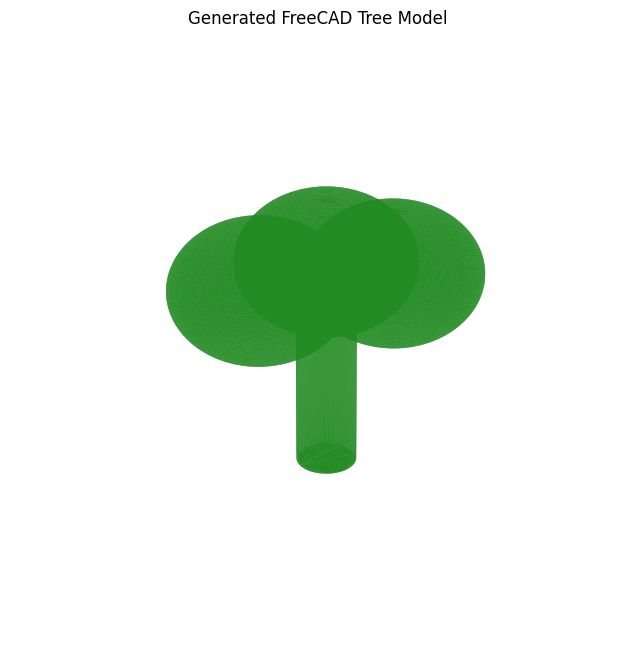

In [27]:
import trimesh
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# 1. Load the original STL
mesh = trimesh.load("model.stl")

# --- GLB CONVERSION ---
# Apply a green color to the mesh so the GLB file has color!
# [R, G, B, Alpha] ->[34, 139, 34, 255] is the RGB equivalent of #228B22
mesh.visual.face_colors = [34, 139, 34, 255]

# Export to GLB format
mesh.export("model.glb")
print("✅ Successfully converted 'model.stl' to 'model.glb'!")
# ----------------------

# 2. Visualize using matplotlib (Your existing code)
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

faces = mesh.faces
vertices = mesh.vertices

# Color the tree green for the plot
poly3d = Poly3DCollection(vertices[faces], facecolors='#228B22', alpha=0.9, linewidths=0)
ax.add_collection3d(poly3d)

# Scale the plot axes evenly
max_range = np.array([mesh.bounds[1][0]-mesh.bounds[0][0],
                      mesh.bounds[1][1]-mesh.bounds[0][1],
                      mesh.bounds[1][2]-mesh.bounds[0][2]]).max() / 2.0
mid_x = (mesh.bounds[1][0]+mesh.bounds[0][0]) * 0.5
mid_y = (mesh.bounds[1][1]+mesh.bounds[0][1]) * 0.5
mid_z = (mesh.bounds[1][2]+mesh.bounds[0][2]) * 0.5

ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

ax.grid(False)
plt.axis('off')
plt.title("Generated FreeCAD Tree Model")
plt.show()
#################live glb viewer#################
from IPython.display import HTML
import base64

# Load GLB as base64
with open("/content/model.glb", "rb") as f:
    glb_data = base64.b64encode(f.read()).decode("utf-8")

HTML(f"""
<iframe srcdoc="
<!DOCTYPE html>
<html lang='en'>
  <head>
    <script type='module' src='https://unpkg.com/@google/model-viewer/dist/model-viewer.min.js'></script>
    <style>html, body {{ margin: 0; height: 100%; }}</style>
  </head>
  <body>
    <model-viewer
      src='data:model/gltf-binary;base64,{glb_data}'
      alt='3D scene'
      auto-rotate
      camera-controls
      background-color='#FFFFFF'
      style='width:100%; height:100%;'>
    </model-viewer>
  </body>
</html>
" width="100%" height="600px" style="border:0;"></iframe>
""")
